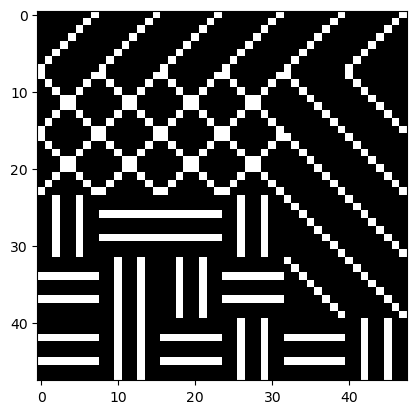

In [114]:
import cv2
from matplotlib import pyplot as plt

image = cv2.imread('data/edge.png', 0)
image_norm = cv2.normalize(image, None, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_32F)
plt.imshow(image_norm, cmap='gray')
plt.show()

In [115]:
print(f"The dimensions of the image are {image_norm.shape}")

The dimensions of the image are (48, 48)


In [116]:
print("\nImage Data:\n", image_norm)


Image Data:
 [[0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 1. 0. 0.]
 ...
 [1. 1. 1. ... 1. 0. 0.]
 [0. 0. 0. ... 1. 0. 0.]
 [0. 0. 0. ... 1. 0. 0.]]


In [117]:
import numpy as np

def apply_conv(image, conv_matrix, padding=0, stride=1):
    h, w = image.shape
    kh, kw = conv_matrix.shape
    image = cv2.copyMakeBorder(image, padding, padding, padding, padding, cv2.BORDER_CONSTANT)
    convolved = np.zeros((h, w), dtype=np.float32)

    pad_h, pad_w = padding, padding
    for y in range(h):
        for x in range(w):
            y_start, x_start = y * stride, x * stride
            window = image[y_start:y_start + kh, x_start:x_start + kw]
            if window.shape == conv_matrix.shape:
                convolved[y, x] = np.sum(window * conv_matrix)

    return convolved

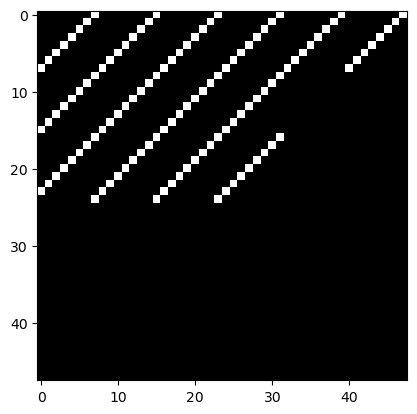

In [118]:
size = 5
sec_diag_matrix = np.fliplr(np.eye(size, dtype=np.float32))  

sec_diag_image = apply_conv(image_norm, sec_diag_matrix, padding=2)

sec_diag_image = (sec_diag_image - sec_diag_image.min()) / (sec_diag_image.max() - sec_diag_image.min())

threshold = 0.5
sec_diag_image = (sec_diag_image > threshold).astype(np.float32)

plt.imshow(sec_diag_image, cmap='gray')
plt.show()

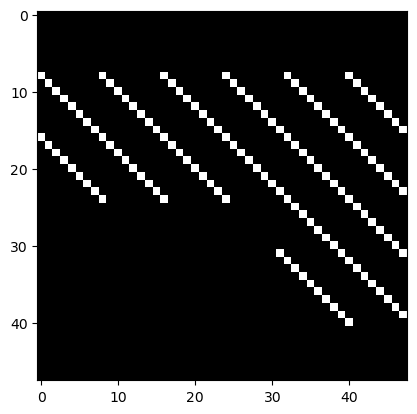

In [119]:
size = 5
main_diag_matrix = np.eye(size, dtype=np.float32)

main_diag_image = apply_conv(image_norm, main_diag_matrix, padding=2)
main_diag_image = (main_diag_image - main_diag_image.min()) / (main_diag_image.max() - main_diag_image.min())
main_diag_image = (main_diag_image > 0.5).astype(np.float32)

plt.imshow(main_diag_image, cmap='gray')
plt.show()

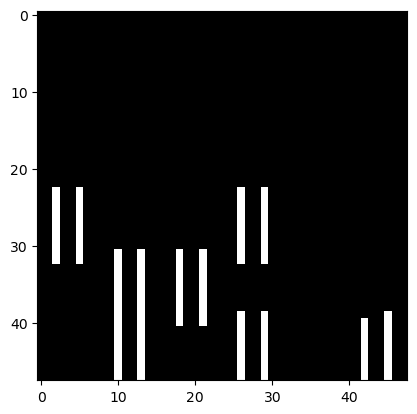

In [120]:
vertical_matrix = np.zeros((size, size), dtype=np.float32)
vertical_matrix[:, size // 2] = 1

vertical_image = apply_conv(image_norm, vertical_matrix, padding=2)
vertical_image = (vertical_image - vertical_image.min()) / (vertical_image.max() - vertical_image.min())
vertical_image = (vertical_image > 0.5).astype(np.float32)

plt.imshow(vertical_image, cmap='gray')
plt.show()

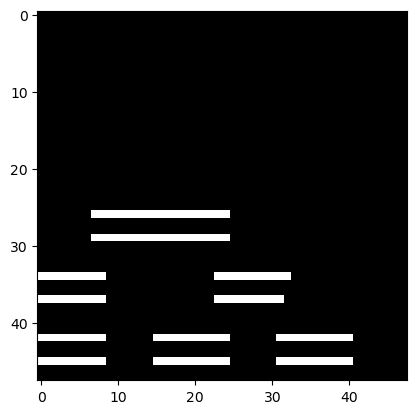

In [121]:
horizontal_matrix = np.zeros((size, size), dtype=np.float32)
horizontal_matrix[size // 2, :] = 1

horizontal_image = apply_conv(image_norm, horizontal_matrix, padding=2)
horizontal_image = (horizontal_image - horizontal_image.min()) / (horizontal_image.max() - horizontal_image.min())
horizontal_image = (horizontal_image > 0.5).astype(np.float32)

plt.imshow(horizontal_image, cmap='gray')
plt.show()

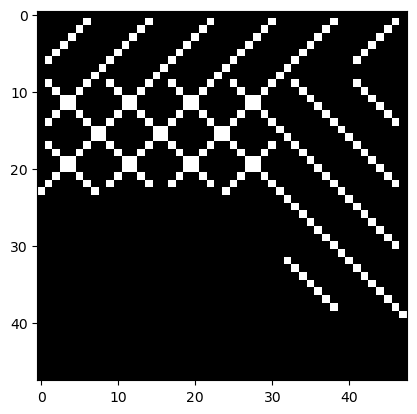

In [122]:
x_matrix = main_diag_matrix + sec_diag_matrix

x_image = apply_conv(image_norm, x_matrix, padding=2)
x_image = (x_image - x_image.min()) / (x_image.max() - x_image.min())
x_image = (x_image > 0.6).astype(np.float32)

plt.imshow(x_image, cmap='gray')
plt.show()